In [1]:
import pandas as pd

In [2]:
transposable_df = pd.read_table("/Users/nikolchantzi/biolab/nonbdna_evolution/notebooks/IR/repeat_masker.hs1.bed", sep="\t", header=None, names=["seqID", "start", "end", "compartment"])
transposable_df = transposable_df[(~(transposable_df["compartment"].str.contains("RNA")))]
transposable_df.loc[:, "compartment"] = transposable_df["compartment"].apply(lambda x: x.split("/")[0] if "/" in x else x)
transposable_df = transposable_df.query("compartment != 'Simple_repeat' & compartment != 'Low_complexity'")
transposable_df = transposable_df[~transposable_df["compartment"].apply(lambda x: "?"  in x)]
transposable_df

,seqID,start,end,compartment
6,chrX,1831,2235,LTR
7,chrX,3589,4061,LTR
8,chrX,4080,4492,LTR
12,chrX,4806,5010,SINE
13,chrX,6871,7022,LTR
...,...,...,...,...
5591072,chrY,62447334,62447430,DNA
5591074,chrY,62448441,62448531,SINE
5591075,chrY,62452004,62452106,DNA
5591076,chrY,62452109,62452299,LINE


In [3]:
from pybedtools import BedTool
transposable_bed = BedTool.from_dataframe(transposable_df).sort()

In [18]:
!find ../../nonbdna_evolution/ -name "chm13*.tsv"

../../nonbdna_evolution/chm13v2.0_STR.processed.tsv


In [13]:
from pybedtools import BedTool 

df_IR = pd.read_table("chm13v2.0_IR.processed.tsv", usecols=["seqID", "start", "end"])
df_IR_bed = BedTool.from_dataframe(df_IR).sort()
df_IR.head()

FileNotFoundError: [Errno 2] No such file or directory: 'chm13v2.0_IR.processed.tsv'

In [9]:
coverage_df = pd.read_table(
        transposable_bed.coverage(df_IR_bed).fn,
        header=None,
        names=["seqID", 
               "start", 
               "end", 
               "compartment", 
               "total_hits", 
               "base_pairs", "compartment_length", "coverage"]
).query("compartment != 'Unknown' & compartment != 'Unspecified'")
coverage_df.loc[:, "coverage"] = coverage_df["coverage"] * 1e3 
sorted_coverage = coverage_df.groupby("compartment")["coverage"].mean().sort_values(ascending=False).index.tolist()
coverage_df

,seqID,start,end,compartment,total_hits,base_pairs,compartment_length,coverage
0,chr1,2710,4398,Satellite,0,0,1688,0.0000
1,chr1,4083,4660,LTR,0,0,577,0.0000
2,chr1,4664,5263,LINE,0,0,599,0.0000
3,chr1,5275,5528,LTR,0,0,253,0.0000
4,chr1,5529,5686,LINE,0,0,157,0.0000
...,...,...,...,...,...,...,...,...
4703974,chrY,62447334,62447430,DNA,0,0,96,0.0000
4703975,chrY,62448441,62448531,SINE,0,0,90,0.0000
4703976,chrY,62452004,62452106,DNA,0,0,102,0.0000
4703977,chrY,62452109,62452299,LINE,0,0,190,0.0000


In [11]:
coverage_df.groupby("compartment")["coverage"].mean().sort_values(ascending=False)

compartment
Satellite     72.152313
SINE          29.982372
Retroposon    27.427830
LINE           8.683443
DNA            6.017898
LTR            5.960812
RC             5.013029
Name: coverage, dtype: float64

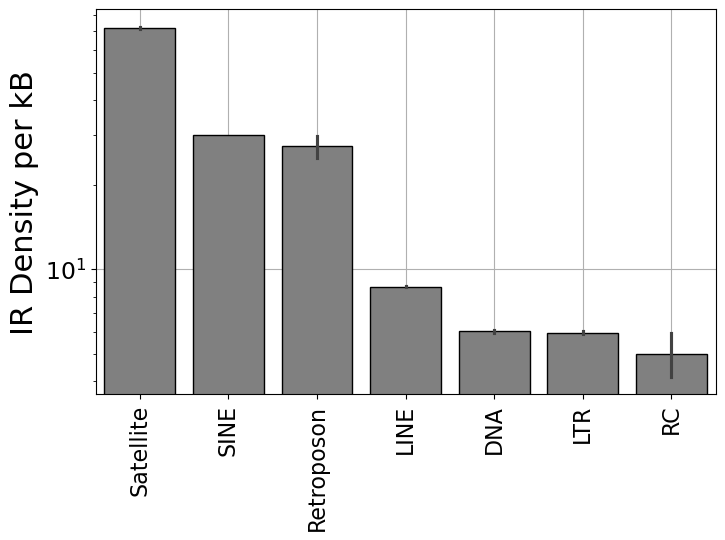

In [12]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
sns.barplot(data=coverage_df,
            x="compartment", 
            color="gray",
            y="coverage", 
            edgecolor="black",
            lw=1.0,
            order=sorted_coverage,
            ax=ax
            )
ax.tick_params(axis='x', labelsize=16, rotation=90)
ax.tick_params(axis='y', labelsize=17)
ax.grid()
ax.set_axisbelow(True)
ax.set_ylabel("IR Density per kB", fontsize=22)
ax.set_xlabel("")
ax.set_yscale("log", base=10)
from pathlib import Path
pattern = "IR"
target = Path(f"{pattern}_figures/IR_repeat_coverage.png")
fig.savefig(target, bbox_inches="tight", transparent=True, dpi=300)

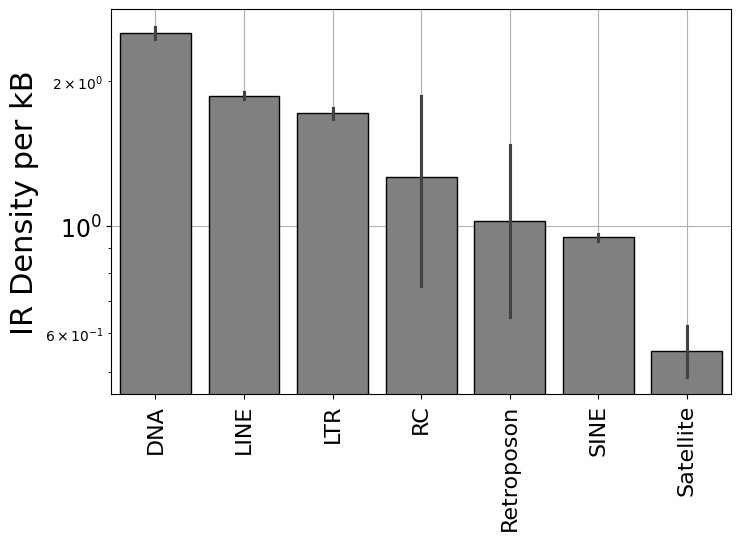

In [47]:
import matplotlib.pyplot as plt 
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
sns.barplot(data=coverage_df,
            x="compartment", 
            color="gray",
            y="coverage", 
            edgecolor="black",
            lw=1.0,
            order=sorted_coverage,
            ax=ax
            )
ax.tick_params(axis='x', labelsize=16, rotation=90)
ax.tick_params(axis='y', labelsize=17)
ax.grid()
ax.set_axisbelow(True)
ax.set_ylabel("IR Density per kB", fontsize=22)
ax.set_xlabel("")
ax.set_yscale("log", base=10)
from pathlib import Path
pattern = "IR"
target = Path(f"{pattern}_figures/IR_repeat_coverage.png")
fig.savefig(target, bbox_inches="tight", transparent=True, dpi=300)